# Basic Usage


In [22]:
%%capture
!pip install autora
!pip install autora[all-theorists]

In [23]:
SEED = 42

def seed_everything(seed=SEED):
    import os, random, numpy as np
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

seed_everything(SEED)

In [24]:
# autora state
from autora.state import StandardState, on_state, Delta

# experiment_runner
from autora.experiment_runner.synthetic.psychophysics.weber_fechner_law import weber_fechner_law
from autora.experiment_runner.synthetic.psychophysics.stevens_power_law import stevens_power_law
from autora.experiment_runner.synthetic.economics.expected_value_theory import expected_value_theory
from autora.experiment_runner.synthetic.psychology.luce_choice_ratio import luce_choice_ratio
from autora.experiment_runner.synthetic.psychology.q_learning import q_learning
from autora.experiment_runner.synthetic.psychology.exp_learning import exp_learning
from autora.experiment_runner.synthetic.economics.expected_value_theory import expected_value_theory
from autora.experiment_runner.synthetic.economics.prospect_theory import prospect_theory
from autora.experiment_runner.synthetic.abstract.lmm import lmm_experiment
from autora.experiment_runner.synthetic.abstract.template_experiment import template_experiment
from autora.experiment_runner.synthetic.neuroscience.task_switching import task_switching


# experimentalist
from autora.experimentalist.grid import grid_pool
from autora.experimentalist.random import random_pool, random_sample

# data handling
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
def benchmark(experiment_runner, theorist):

  # generate all conditions
  conditions = experiment_runner.domain()

  # generate all corresponding observations
  experiment_data = experiment_runner.run(conditions, added_noise=0.01)

  # get the name of the independent and independent variables
  ivs = [iv.name for iv in experiment_runner.variables.independent_variables]
  dvs = [dv.name for dv in experiment_runner.variables.dependent_variables]

  # extract the dependent variable (observations) from experiment data
  conditions = experiment_data[ivs]
  observations = experiment_data[dvs]

  # split into train and test datasets
  conditions_train, conditions_test, observations_train, observations_test = train_test_split(conditions, observations)

  print("#### EXPERIMENT CONDITIONS (X):")
  print(conditions)
  print("#### EXPERIMENT OBSERVATIONS (Y):")
  print(observations)


#Demonstrating how to use the theorist for fitting:

  # fit theorist
  theorist.fit(conditions_train, observations_train)


#Demonstrating how to use the theorist for predicting:
  # compute prediction for validation set
  predictions = theorist.predict(conditions_test)

  # evaluate theorist performance
  error = (predictions - observations_test).pow(2)
  error = error.mean()

#Demonstrating how to obtain the equation fit by the theorist:

  print("#### IDENTIFIED EQUATION:")
  print(theorist.print_eqn())

  print("#### VALIDATION SET MSE:")
  print(error)

  experiment_runner.plotter(model=theorist)
  plt.show()

In [10]:
Demonstrating that the theorist can recover at least two ground truth models. (*Hint: You could use the benchmarking part of the notebook below as a starting point*).


     - Stevens’ Power Law  
     - Weber–Fechner Law  
     - Expected Value Theory

SyntaxError: invalid character '’' (U+2019) (3849089010.py, line 4)

In [26]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


class PolynomialRegressor:
    """
    This theorist fits a polynomial function to the data.
    """

    def __init__(self, degree: int = 3):
      self.poly = PolynomialFeatures(degree=degree, include_bias=False)
      self.model = LinearRegression()

    def fit(self, x, y):
      features = self.poly.fit_transform(x, y)
      self.model.fit(features, y)
      return self

    def predict(self, x):
      features = self.poly.fit_transform(x)
      return self.model.predict(features)

    def print_eqn(self):
        # Extract the coefficients and intercept
        coeffs = self.model.coef_
        intercept = self.model.intercept_

        # Handle multi-output case by iterating over each output's coefficients and intercept
        if coeffs.ndim > 1:
            for idx in range(coeffs.shape[0]):
                equation = f"y{idx+1} = {intercept[idx]:.3f}"
                feature_names = self.poly.get_feature_names_out()
                for coef, feature in zip(coeffs[idx], feature_names):
                    equation += f" + ({coef:.3f}) * {feature}"
                print(equation)
        else:
            equation = f"y = {intercept:.3f}"
            feature_names = self.poly.get_feature_names_out()
            for coef, feature in zip(coeffs, feature_names):
                equation += f" + ({coef:.3f}) * {feature}"
            print(equation)

dummy_theorist = PolynomialRegressor()

In [27]:
# Our theorist
Our theorist is a piecewise sparse symbolic model 

Our computation graph:

1. Gating (optional, piecewise): KMeans assigns each xx to a region cc (0–k−1k−1).

2. Feature transforms: For each region we compute simple, interpretable primitives of the inputs:
    fj(x)∈{xi,  xi2,  xixj,  ln⁡(xi+ϵ),  (xi+ϵ)c,  xi/(xi+xj+ϵ),  1/(xi+ϵ)}fj​(x)∈{xi​,xi2​,xi​xj​,ln(xi​+ϵ),(xi​+ϵ)c,xi​/(xi​+xj​+ϵ),1/(xi​+ϵ)}.

3. Sparse linear comb (learned):
    y^=βc,0+∑j∈Scβc,j fj(x)y^​=βc,0​+∑j∈Sc​​βc,j​fj​(x)
    where ScSc​ is a small subset chosen by OMP (sparsity).

4. Model selection: we search over degree (1 or 2) and #chunks kk, and pick the argmin of validation MSE + tiny complexity penalty, under a global ≤ 40-symbol budget.

So it’s a piecewise, linear-in-parameters, symbolic model built from allowed ops. Discovery happens by:

- Choosing the structure: number of chunks kk, which features are included (subset ScSc​), and degree.

- Estimating constants: the ββ coefficients (and fixed exponents if you include powers like 0.5,1.50.5,1.5).


**Acronyms**:

**OLS**: Ordinary Least Squares

- Fit all chosen features at once by minimizing squared error:
min⁡β∥y−Fβ∥2minβ​∥y−Fβ∥2. No sparsity by itself; every included feature gets a (usually non-zero) weight.
**OMP**: Orthogonal Matching Pursuit

- A greedy sparse method: it picks one feature at a time—the one most correlated with the current residual—then re-fits coefficients on the selected set (via least squares) and updates the residual. Repeat until you’ve picked k features (your cap) or the residual is tiny.


SyntaxError: invalid character '–' (U+2013) (1683533564.py, line 6)

In [29]:
import numpy as np
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, OrthogonalMatchingPursuit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Feature library with allowed ops
# -------------------------------
class FeatureLibrary:
    """
    Allowed ops:
      - linear: x_i
      - degree<=2 polys: x_i^2, (optional) x_i*x_j
      - logs: ln(x_i + shift_i)
      - powers: (x_i + shift_i)^c for c in allowed_powers
    Safe for non-positive inputs via learned shifts.
    """
    def __init__(
        self,
        include_interactions=True,
        include_logs=True,
        allowed_powers=(0.5, 1.5),
        eps=1e-8,
        random_state=0,
    ):
        self.include_interactions = include_interactions
        self.include_logs = include_logs
        self.allowed_powers = tuple(float(c) for c in allowed_powers)
        self.eps = float(eps)
        self.random_state = random_state
        self.log_shifts_ = None
        self.pow_shifts_ = None
        self.n_features_in_ = None

    def _ensure_2d(self, X):
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return X

    def fit(self, X):
        X = self._ensure_2d(X)
        self.n_features_in_ = X.shape[1]
        mins = np.nanmin(X, axis=0)
        self.log_shifts_ = np.maximum(self.eps - mins, 0.0)
        self.pow_shifts_ = np.maximum(self.eps - mins, 0.0)
        return self

    def transform(self, X, degree=2):
        assert self.n_features_in_ is not None, "Call fit() first."
        X = self._ensure_2d(X)
        n, d = X.shape
        assert d == self.n_features_in_, "Feature dimension mismatch."

        feats, names = [], []

        # linear
        for i in range(d):
            feats.append(X[:, i:i+1])
            names.append(f"x{i}")

        # degree-2
        if degree >= 2:
            for i in range(d):
                feats.append(X[:, i:i+1] ** 2)
                names.append(f"x{i}^2")
            if self.include_interactions and d > 1:
                for i, j in combinations(range(d), 2):
                    feats.append((X[:, i:i+1] * X[:, j:j+1]))
                    names.append(f"x{i}*x{j}")

        # logs
        if self.include_logs:
            for i in range(d):
                shifted = np.maximum(X[:, i] + self.log_shifts_[i], self.eps)
                feats.append(np.log(shifted).reshape(-1, 1))
                s = self.log_shifts_[i]
                names.append(f"ln(x{i}+{s:.3g})" if s > 0 else f"ln(x{i})")

        # small power set
        for c in self.allowed_powers:
            if abs(c - 1.0) < 1e-12:
                continue
            for i in range(d):
                shifted = np.maximum(X[:, i] + self.pow_shifts_[i], self.eps)
                feats.append((shifted ** c).reshape(-1, 1))
                s = self.pow_shifts_[i]
                names.append(f"(x{i}+{s:.3g})^{c:.3g}" if s > 0 else f"x{i}^{c:.3g}")

        F = np.hstack(feats) if feats else np.empty((n, 0))
        return F, names


# -----------------------------------------------
# Sparse linear model (OMP) + OLS refit on support
# -----------------------------------------------
class SparseLinearBlock:
    """
    Select up to term_cap features via OMP (on standardized features),
    then refit OLS on the selected features (original scale).
    Handles multi-output by unioning supports and pruning to term_cap.
    """
    def __init__(self, term_cap=6, random_state=0):
        self.term_cap = int(term_cap)
        self.random_state = random_state
        self.active_idx_ = None
        self.lr_ = None
        self.feature_names_ = None
        self.coef_ = None
        self.intercept_ = None

    def fit(self, F, y, feature_names):
        F = np.asarray(F); y = np.asarray(y)
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        # standardize F (mean-0, unit-var), center y (mean-0)
        scalerF = StandardScaler(with_mean=True, with_std=True)
        Fy = scalerF.fit_transform(F)
        y_mean = y.mean(axis=0, keepdims=True)
        y_c = y - y_mean

        # OMP per target -> union support
        max_atoms = max(1, min(self.term_cap, Fy.shape[1], max(1, Fy.shape[0] - 1)))
        supports = []
        coef_store = []  # to score features if we need to prune
        for t in range(y_c.shape[1]):
            omp = OrthogonalMatchingPursuit(
                n_nonzero_coefs=max_atoms,
                fit_intercept=False,  # we centered y and standardized X
            )
            omp.fit(Fy, y_c[:, t])
            coef = getattr(omp, "coef_", None)
            if coef is None:
                continue
            coef_store.append(np.abs(coef))
            supports.append(set(np.flatnonzero(np.abs(coef) > 0).tolist()))

        if supports:
            active = sorted(list(set.union(*supports)))
        else:
            active = []

        # If nothing selected, pick best by correlation
        if len(active) == 0:
            corr = np.abs(Fy.T @ y_c).sum(axis=1)  # aggregate over targets
            best = int(np.argmax(corr))
            active = [best]

        # Prune union to term_cap if needed (by aggregate correlation with y)
        if len(active) > self.term_cap:
            corr = np.abs(Fy.T @ y_c).sum(axis=1)
            order = np.argsort(-corr[active])  # descending
            active = [active[i] for i in order[: self.term_cap]]

        self.active_idx_ = np.array(active, dtype=int)

        # OLS refit on selected features (original scale)
        F_sel = F[:, self.active_idx_]
        lr = LinearRegression()
        lr.fit(F_sel, y)
        self.lr_ = lr
        self.feature_names_ = [feature_names[j] for j in self.active_idx_]

        coef = lr.coef_
        if coef.ndim == 1:
            coef = coef.reshape(1, -1)
        self.coef_ = coef
        self.intercept_ = lr.intercept_.ravel()
        return self

    def predict(self, F):
        F = np.asarray(F)
        F_sel = F[:, self.active_idx_]
        return self.lr_.predict(F_sel)

    def n_terms(self):
        return 0 if self.active_idx_ is None else len(self.active_idx_)


# --------------------------------------------------------
# Chunked sparse polynomial regressor with symbol budgeting
# --------------------------------------------------------
class ChunkedPolynomialRegressorSparse:
    """
    Piecewise sparse regression with global symbol budget.
    Search: degree ∈ {1,2}, k ∈ {0..max_chunks}.
    """
    def __init__(
        self,
        max_chunks=4,
        max_degree=2,
        max_symbols=40,
        include_interactions=True,
        include_logs=True,
        allowed_powers=(0.5, 1.5),
        lambda_complexity=1e-4,
        random_state=0,
    ):
        self.max_chunks = int(max_chunks)
        self.max_degree = int(max_degree)
        self.max_symbols = int(max_symbols)
        self.lambda_complexity = float(lambda_complexity)
        self.random_state = random_state

        self.library = FeatureLibrary(
            include_interactions=include_interactions,
            include_logs=include_logs,
            allowed_powers=allowed_powers,
            random_state=random_state,
        )

        self.best_degree = None
        self.best_k = None
        self.clusterer = None
        self.cluster_labels = None
        self.cluster_scaler_ = None  # <-- store scaler used for clustering
        self.blocks = []
        self.feature_names_ = None
        self.mse_per_config = {}

        self.X_fit = None
        self.y_fit = None

    def _symbol_count(self, blocks):
        # 1 intercept per chunk + #selected terms
        return sum(1 + b.n_terms() for b in blocks)

    def _fit_blocks_for_k(self, X, y, degree, k):
        n = X.shape[0]

        if k == 0:
            labels = np.zeros(n, dtype=int)
            clusterer = None
            self.cluster_scaler_ = None
            per_chunk_cap = max(1, self.max_symbols - 1)
        else:
            # scaler & kmeans on training data; store scaler
            self.cluster_scaler_ = StandardScaler(with_mean=True, with_std=True).fit(X)
            Xs = self.cluster_scaler_.transform(X)
            clusterer = KMeans(n_clusters=k, n_init=10, random_state=self.random_state)
            labels = clusterer.fit_predict(Xs)
            # conservative per-chunk cap so total <= max_symbols
            per_chunk_cap = max(1, (self.max_symbols - k) // k)

        blocks = []
        preds = np.zeros_like(y, dtype=float)
        n_chunks = 1 if k == 0 else k

        for cid in range(n_chunks):
            idx = np.where(labels == cid)[0]
            if idx.size == 0:
                return None, None, np.inf, np.inf

            F, names = self.library.transform(X[idx], degree=degree)
            if F.shape[1] == 0:
                return None, None, np.inf, np.inf

            # Cap term_cap to available features/samples (extra safety for OMP)
            safe_cap = max(1, min(per_chunk_cap, F.shape[1], max(1, F.shape[0] - 1)))
            block = SparseLinearBlock(term_cap=safe_cap, random_state=self.random_state)
            block.fit(F, y[idx], names)

            preds[idx] = block.predict(F)
            blocks.append(block)

        # budget check
        scount = self._symbol_count(blocks)
        if scount > self.max_symbols:
            return None, None, np.inf, np.inf

        mse = mean_squared_error(y, preds)
        return blocks, (clusterer, labels), mse, scount

    def fit(self, X, y):
        X = np.asarray(X); y = np.asarray(y)
        if X.ndim == 1: X = X.reshape(-1, 1)
        if y.ndim == 1: y = y.reshape(-1, 1)

        self.X_fit = X
        self.y_fit = y
        self.library.fit(X)

        best = None
        best_score = np.inf
        self.mse_per_config = {}

        max_k = min(self.max_chunks, X.shape[0])

        for degree in range(1, self.max_degree + 1):
            for k in range(0, max_k + 1):
                blocks, pack, mse, scount = self._fit_blocks_for_k(X, y, degree, k)
                self.mse_per_config[(degree, k)] = (mse, scount)
                if not np.isfinite(mse):
                    continue
                score = mse + self.lambda_complexity * scount
                if score < best_score - 1e-12:
                    best_score = score
                    best = (degree, k, blocks, pack)

        if best is None:
            raise RuntimeError("❌ No feasible (degree, k) under the symbol budget.")

        self.best_degree, self.best_k, self.blocks, pack = best
        if self.best_k == 0:
            self.clusterer, self.cluster_labels = None, np.zeros(X.shape[0], dtype=int)
            self.cluster_scaler_ = None
        else:
            self.clusterer, self.cluster_labels = pack

        # cache names for printing (consistent for a given degree)
        _, names_tmp = self.library.transform(X, degree=self.best_degree)
        self.feature_names_ = names_tmp
        return self

    def predict(self, X):
        X = np.asarray(X)
        if X.ndim == 1: X = X.reshape(-1, 1)

        if self.best_k == 0:
            F, _ = self.library.transform(X, degree=self.best_degree)
            return self.blocks[0].predict(F)

        # use the SAME scaler used at fit-time for clustering
        Xs_new = self.cluster_scaler_.transform(X)
        labels = self.clusterer.predict(Xs_new)

        yhat = np.zeros((X.shape[0], self.y_fit.shape[1]))
        for cid, block in enumerate(self.blocks):
            idx = np.where(labels == cid)[0]
            if idx.size == 0:
                continue
            F, _ = self.library.transform(X[idx], degree=self.best_degree)
            yhat[idx] = block.predict(F)
        return yhat

    # Print the clusters
    def print_clusters(self, feature_names=None, quantiles=(0, 50, 100), digits=5):
        """
        Describe KMeans clusters in original input units.
        - feature_names: list like ['S1','S2'] (defaults to ['x0','x1',...])
        - quantiles: which percentiles to report per feature (e.g., (5,50,95))
        """
        if self.best_k == 0 or self.clusterer is None:
            print("No clustering: global model (k=0).")
            return

        X = self.X_fit
        n, d = X.shape
        names = feature_names or [f"x{i}" for i in range(d)]

        # Labels for training data using the stored scaler
        labels = self.clusterer.predict(self.cluster_scaler_.transform(X))

        # Centroids back in original units
        centers_std = self.clusterer.cluster_centers_
        centers_orig = self.cluster_scaler_.inverse_transform(centers_std)

        print(f"\n🔎 Cluster summary (k={self.best_k}):")
        for cid in range(self.best_k):
            idx = np.where(labels == cid)[0]
            if idx.size == 0:
                print(f"\n  • Region {cid+1}: [empty]")
                continue

            Xc = X[idx]
            c = centers_orig[cid]
            print(f"\n  • Region {cid+1}: n={len(idx)}")
            print("    center: " + ", ".join(f"{names[j]}={c[j]:.{digits}g}" for j in range(d)))

            # Per-feature quantile ranges in original units
            for j in range(d):
                qs = np.percentile(Xc[:, j], q=list(quantiles))
                qstr = " | ".join([f"q{int(q)}={val:.{digits}g}" for q, val in zip(quantiles, qs)])
                print(f"    {names[j]}: {qstr}")

            # Mean radius in standardized space (how tight the cluster is)
            dists = np.linalg.norm(self.cluster_scaler_.transform(Xc) - centers_std[cid], axis=1)
            print(f"    mean radius (std units): {np.mean(dists):.{digits}g} ± {np.std(dists):.{digits}g}")

        # For 1D, also print approximate cutpoints (midpoints between sorted centroids)
        if d == 1:
            order = np.argsort(centers_orig[:, 0])
            cuts = [(centers_orig[order[i], 0] + centers_orig[order[i+1], 0]) / 2
                    for i in range(len(order) - 1)]
            if cuts:
                print("\n  approx cutpoints (1D): " + ", ".join(f"{v:.{digits}g}" for v in cuts))

    # ------------- pretty printing -------------
    def _equation_str(self, block, out_idx=0):
        coef = block.coef_[out_idx]
        if coef.size == 0:
            return f"y{out_idx+1} = {block.intercept_[out_idx]:.6g}"
        terms = [f"({c:.6g})*{name}" for c, name in zip(coef, block.feature_names_)]
        return f"y{out_idx+1} = {block.intercept_[out_idx]:.6g} + " + " + ".join(terms)

    def print_eqn(self, max_outputs=1):
        print("\n📊 Scores for (degree, chunks):")
        for (deg, k), (mse, scount) in sorted(self.mse_per_config.items()):
            mark = " (global)" if k == 0 else ""
            print(f"  - degree={deg}, k={k}{mark}: MSE={mse:.6g}, symbols={scount}")

        print(f"\n✅ Final selection: degree={self.best_degree}, chunk count={self.best_k}")
        total_symbols = self._symbol_count(self.blocks)
        print(f"   Total symbols: {total_symbols} (budget ≤ {self.max_symbols})")

        # brief cluster summary so the regions are interpretable
        if self.best_k > 0:
            # pass raw feature names if you have them, e.g. ['S1','S2']
            self.print_clusters(feature_names=None, quantiles=(5, 50, 95))

        if self.best_k == 0:
            preds = self.predict(self.X_fit)
            mse = mean_squared_error(self.y_fit, preds)
            print(f"\n🔹 Global Model: n={len(self.X_fit)}, MSE={mse:.6g}")
            for j in range(min(max_outputs, self.y_fit.shape[1])):
                print(self._equation_str(self.blocks[0], out_idx=j))
            return

        # piecewise: recompute training labels with stored scaler
        labels = self.clusterer.predict(self.cluster_scaler_.transform(self.X_fit))
        for cid, block in enumerate(self.blocks):
            idx = np.where(labels == cid)[0]
            if idx.size == 0:
                print(f"\n🔹 Region {cid+1}: [Empty]")
                continue
            preds = self.predict(self.X_fit[idx])
            mse = mean_squared_error(self.y_fit[idx], preds)
            print(f"\n🔹 Region {cid+1}: n={len(idx)}, MSE={mse:.6g}")
            for j in range(min(max_outputs, self.y_fit.shape[1])):
                print(self._equation_str(block, out_idx=j))


# -----------------------------
# Instantiate your new theorist
# -----------------------------
chunk_theorist = ChunkedPolynomialRegressorSparse(
    max_chunks=4,
    max_degree=2,
    max_symbols=36,
    include_interactions=True,
    include_logs=True,
    allowed_powers=(0.5, 1.5),
    lambda_complexity=1e-4,
    random_state=0,
)

In [16]:
# Run only in case .src method doesn't work

# *Add src folder onto sys.path
import sys, os

# assuming your notebook lives one level above src/
HERE = os.path.dirname(os.path.abspath("__file__"))
SRC  = os.path.join(HERE, "src")
sys.path.insert(0, SRC)

In [17]:
import os
os.chdir('..')

from src.autora.theorist.maft import ChunkedPolynomialRegressorSparse, chunk_theorist

theorist = chunk_theorist

#### EXPERIMENT CONDITIONS (X):
           S
0   0.010000
1   0.060404
2   0.110808
3   0.161212
4   0.211616
..       ...
95  4.798384
96  4.848788
97  4.899192
98  4.949596
99  5.000000

[100 rows x 1 columns]
#### EXPERIMENT OBSERVATIONS (Y):
    perceived_intensity
0              0.035927
1              0.093722
2              0.157923
3              0.228249
4              0.288762
..                  ...
95             3.498084
96             3.532051
97             3.559848
98             3.590513
99             3.609912

[100 rows x 1 columns]
#### IDENTIFIED EQUATION:

📊 Scores for (degree, chunks):
  - degree=1, k=0 (global): MSE=0.000104002, symbols=5
  - degree=1, k=1: MSE=0.000104002, symbols=5
  - degree=1, k=2: MSE=9.85948e-05, symbols=10
  - degree=1, k=3: MSE=9.33355e-05, symbols=15
  - degree=1, k=4: MSE=8.56493e-05, symbols=20
  - degree=2, k=0 (global): MSE=0.000103895, symbols=6
  - degree=2, k=1: MSE=0.000103895, symbols=6
  - degree=2, k=2: MSE=9.38924e-05, symbo

/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)


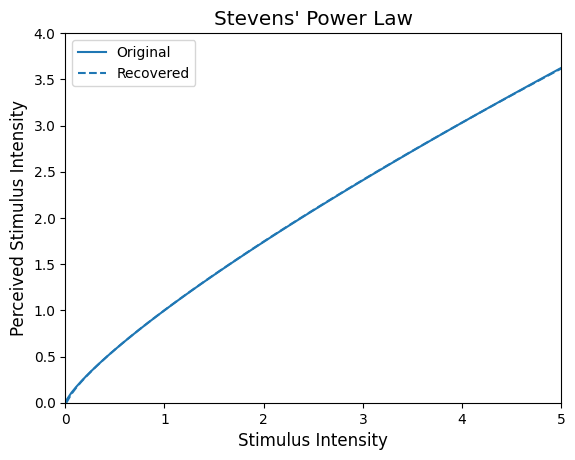

#### EXPERIMENT CONDITIONS (X):
            S1        S2
0     0.010000  0.010000
1     0.010000  0.060404
2     0.010000  0.110808
3     0.010000  0.161212
4     0.010000  0.211616
...        ...       ...
5045  4.899192  4.949596
5046  4.899192  5.000000
5047  4.949596  4.949596
5048  4.949596  5.000000
5049  5.000000  5.000000

[5050 rows x 2 columns]
#### EXPERIMENT OBSERVATIONS (Y):
      difference_detected
0               -0.010591
1                1.791564
2                2.412022
3                2.777561
4                3.043806
...                   ...
5045             0.021580
5046             0.016954
5047            -0.015724
5048             0.020005
5049            -0.005295

[5050 rows x 1 columns]
#### IDENTIFIED EQUATION:

📊 Scores for (degree, chunks):
  - degree=1, k=0 (global): MSE=9.98275e-05, symbols=9
  - degree=1, k=1: MSE=9.98275e-05, symbols=9
  - degree=1, k=2: MSE=9.96263e-05, symbols=18
  - degree=1, k=3: MSE=9.95153e-05, symbols=27
  - degree=1, k=4: 

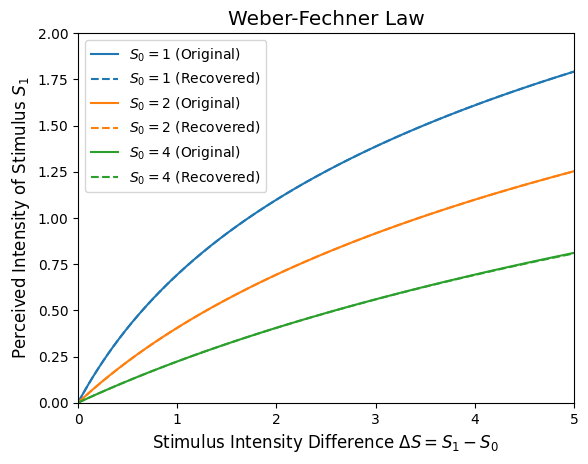

#### EXPERIMENT CONDITIONS (X):
        V_A       P_A       V_B       P_B
0 -1.000000 -0.777778 -0.555556 -0.333333
1 -0.111111  0.111111  0.333333  0.555556
2  0.777778  1.000000  0.000000  0.111111
3  0.222222  0.333333  0.444444  0.555556
4  0.666667  0.777778  0.888889  1.000000
5 -1.000000 -0.777778 -0.555556 -0.333333
6 -0.111111  0.111111  0.333333  0.555556
7  0.777778  1.000000  0.000000  0.111111
8  0.222222  0.333333  0.444444  0.555556
9  0.666667  0.777778  0.888889  1.000000
#### EXPERIMENT OBSERVATIONS (Y):
   choose_A
0  0.950827
1  0.256179
2  0.981920
3  0.268365
4  0.106097
5  0.943086
6  0.205786
7  0.976933
8  0.276164
9  0.134321
#### IDENTIFIED EQUATION:

📊 Scores for (degree, chunks):
  - degree=1, k=0 (global): MSE=6.29542e-05, symbols=4
  - degree=1, k=1: MSE=6.29542e-05, symbols=4
  - degree=1, k=2: MSE=6.29542e-05, symbols=5
  - degree=1, k=3: MSE=6.29542e-05, symbols=6
  - degree=1, k=4: MSE=6.29542e-05, symbols=8
  - degree=2, k=0 (global): MSE=6.29542e-05

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_omp.py:445: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  out = _cholesky_omp(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_omp.py:445: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  out = _cholesky_omp(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_omp.py:445: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  out = _cholesky_omp(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_omp.py:445: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested pr

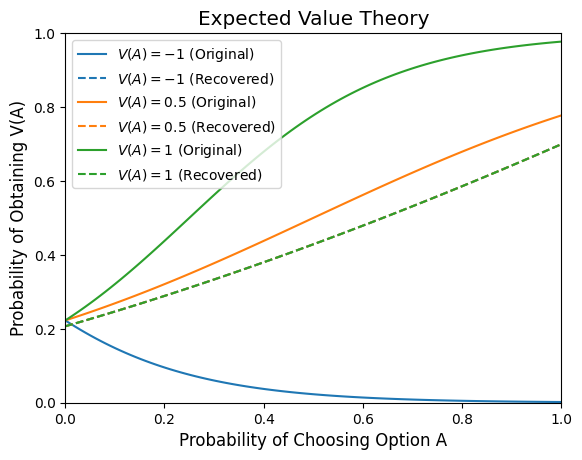

#### EXPERIMENT CONDITIONS (X):
      similarity_category_A1  similarity_category_A2  similarity_category_B1  \
0                        0.1                0.100000                     0.1   
1                        0.1                1.514286                     0.1   
2                        0.1                2.928571                     0.1   
3                        0.1                4.342857                     0.1   
4                        0.1                5.757143                     0.1   
...                      ...                     ...                     ...   
4091                    10.0                4.342857                    10.0   
4092                    10.0                5.757143                    10.0   
4093                    10.0                7.171429                    10.0   
4094                    10.0                8.585714                    10.0   
4095                    10.0               10.000000                    10.0   

      s

/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)


#### IDENTIFIED EQUATION:

📊 Scores for (degree, chunks):
  - degree=1, k=0 (global): MSE=0.00228831, symbols=17
  - degree=1, k=1: MSE=0.00228831, symbols=17
  - degree=1, k=2: MSE=0.00201035, symbols=32
  - degree=1, k=3: MSE=0.000996994, symbols=36
  - degree=1, k=4: MSE=0.000931258, symbols=36
  - degree=2, k=0 (global): MSE=0.00113126, symbols=27
  - degree=2, k=1: MSE=0.00113126, symbols=27
  - degree=2, k=2: MSE=0.00103818, symbols=36
  - degree=2, k=3: MSE=0.000474876, symbols=36
  - degree=2, k=4: MSE=0.000563053, symbols=36

✅ Final selection: degree=1, chunk count=0
   Total symbols: 17 (budget ≤ 36)

🔹 Global Model: n=3072, MSE=0.00228831
y1 = 0.00928227 + (-0.0504708)*x0 + (-0.0143146)*x1 + (-0.0693385)*x2 + (-0.00169902)*x3 + (-0.0635925)*ln(x0) + (0.021419)*ln(x1) + (-0.0338093)*ln(x2) + (0.00374937)*ln(x3) + (0.469642)*x0^0.5 + (-0.15218)*x1^0.5 + (0.170649)*x2^0.5 + (-0.0262729)*x3^0.5 + (0.00102572)*x0^1.5 + (0.00497782)*x1^1.5 + (0.00857703)*x2^1.5 + (-0.000437722)*x

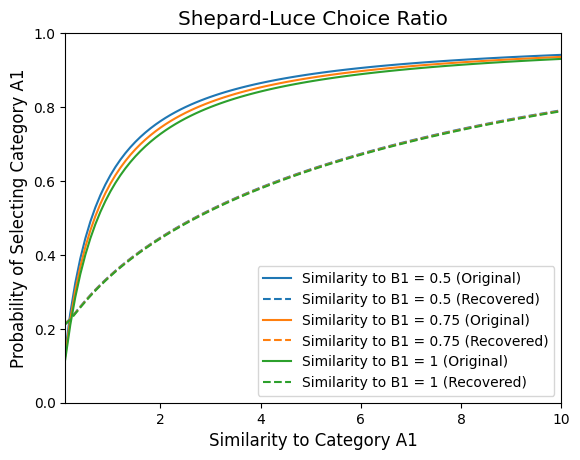

#### EXPERIMENT CONDITIONS (X):
      P_asymptotic  trial
0              0.0    1.0
1              0.0    2.0
2              0.0    3.0
3              0.0    4.0
4              0.0    5.0
...            ...    ...
9995           0.5   96.0
9996           0.5   97.0
9997           0.5   98.0
9998           0.5   99.0
9999           0.5  100.0

[10000 rows x 2 columns]
#### EXPERIMENT OBSERVATIONS (Y):
      performance
0        0.044350
1        0.056164
2        0.090719
3        0.113124
4        0.132347
...           ...
9995     0.981089
9996     0.970897
9997     1.002009
9998     0.958064
9999     0.977790

[10000 rows x 1 columns]
#### IDENTIFIED EQUATION:

📊 Scores for (degree, chunks):
  - degree=1, k=0 (global): MSE=0.00145639, symbols=9
  - degree=1, k=1: MSE=0.00145639, symbols=9
  - degree=1, k=2: MSE=0.000612936, symbols=18
  - degree=1, k=3: MSE=0.000314219, symbols=27
  - degree=1, k=4: MSE=0.000227527, symbols=36
  - degree=2, k=0 (global): MSE=0.000267548, symbols=12


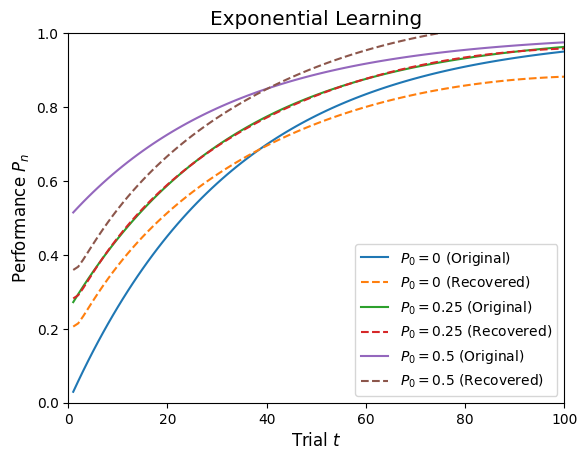

#### EXPERIMENT CONDITIONS (X):
      V_A       P_A  V_B  P_B
0    -1.0  0.000000 -1.0  0.0
1    -1.0  0.111111 -1.0  0.0
2    -1.0  0.222222 -1.0  0.0
3    -1.0  0.333333 -1.0  0.0
4    -1.0  0.444444 -1.0  0.0
...   ...       ...  ...  ...
9995  1.0  0.555556  1.0  1.0
9996  1.0  0.666667  1.0  1.0
9997  1.0  0.777778  1.0  1.0
9998  1.0  0.888889  1.0  1.0
9999  1.0  1.000000  1.0  1.0

[10000 rows x 4 columns]
#### EXPERIMENT OBSERVATIONS (Y):
      choose_A
0     0.479623
1     0.016435
2     0.002533
3     0.000261
4     0.000088
...        ...
9995  0.004112
9996  0.007235
9997  0.015904
9998  0.044982
9999  0.513648

[10000 rows x 1 columns]
#### IDENTIFIED EQUATION:

📊 Scores for (degree, chunks):
  - degree=1, k=0 (global): MSE=0.0660416, symbols=17
  - degree=1, k=1: MSE=0.0660416, symbols=17
  - degree=1, k=2: MSE=0.053626, symbols=34
  - degree=1, k=3: MSE=0.0415091, symbols=36
  - degree=1, k=4: MSE=0.030802, symbols=36
  - degree=2, k=0 (global): MSE=0.034535, symbols=27

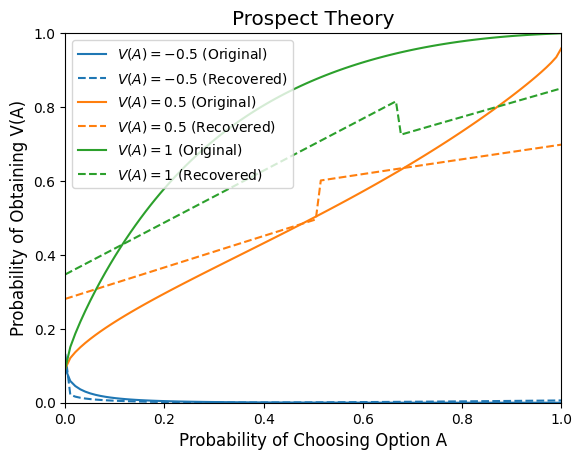

#### EXPERIMENT CONDITIONS (X):
      cur_task_strength  alt_task_strength  is_switch
0                  0.02               0.02        0.0
1                  0.02               0.04        0.0
2                  0.02               0.06        0.0
3                  0.02               0.08        0.0
4                  0.02               0.10        0.0
...                 ...                ...        ...
4995               1.00               0.92        1.0
4996               1.00               0.94        1.0
4997               1.00               0.96        1.0
4998               1.00               0.98        1.0
4999               1.00               1.00        1.0

[5000 rows x 3 columns]
#### EXPERIMENT OBSERVATIONS (Y):
      cur_task_performance
0                 0.917248
1                 0.906839
2                 0.901257
3                 0.883920
4                 0.854706
...                    ...
4995              0.534960
4996              0.535110
4997              

/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linea

#### IDENTIFIED EQUATION:

📊 Scores for (degree, chunks):
  - degree=1, k=0 (global): MSE=0.000984411, symbols=10
  - degree=1, k=1: MSE=0.000984411, symbols=10
  - degree=1, k=2: MSE=0.000163819, symbols=18
  - degree=1, k=3: MSE=0.0001412, symbols=27
  - degree=1, k=4: MSE=8.17284e-05, symbols=36
  - degree=2, k=0 (global): MSE=0.000638205, symbols=15
  - degree=2, k=1: MSE=0.000638205, symbols=15
  - degree=2, k=2: MSE=0.000109278, symbols=24
  - degree=2, k=3: MSE=9.61743e-05, symbols=36
  - degree=2, k=4: MSE=6.14357e-05, symbols=36

✅ Final selection: degree=1, chunk count=0
   Total symbols: 10 (budget ≤ 36)

🔹 Global Model: n=3750, MSE=0.000984411
y1 = 1.31927 + (2.56627)*x0 + (-2.11703)*x1 + (-0.152362)*x2 + (0.125726)*ln(x0) + (-0.0704132)*ln(x1) + (-2.33192)*x0^0.5 + (1.30199)*x1^0.5 + (-0.927406)*x0^1.5 + (0.846952)*x1^1.5
None
#### VALIDATION SET MSE:
cur_task_performance    0.000992
dtype: float64


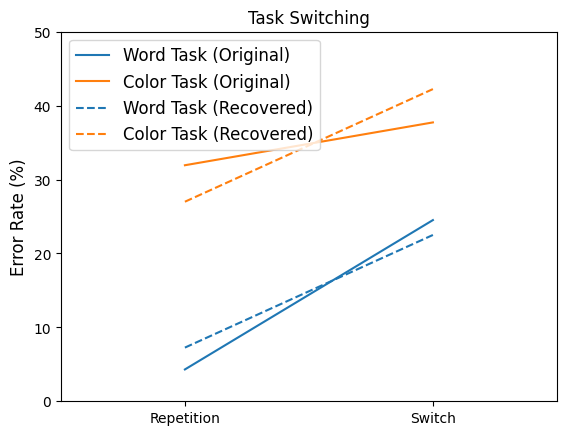

In [30]:
#########################################
######## Bench-Marking Combined #########
#########################################

# Benchmark 1) stevens_power_law
# Benchmark 2) weber_fechner_law
# Benchmark 3) expected_value_theory

# luce_choice_ratio
# exp_learning
# prospect_theory
# task_switching


# run benchmark
experiment_runners = [stevens_power_law, weber_fechner_law, expected_value_theory, luce_choice_ratio, exp_learning, prospect_theory, task_switching]
for experiment in experiment_runners:
    benchmark(experiment_runner = experiment(), theorist = theorist)

#### EXPERIMENT CONDITIONS (X):
           S
0   0.010000
1   0.060404
2   0.110808
3   0.161212
4   0.211616
..       ...
95  4.798384
96  4.848788
97  4.899192
98  4.949596
99  5.000000

[100 rows x 1 columns]
#### EXPERIMENT OBSERVATIONS (Y):
    perceived_intensity
0              0.038293
1              0.109200
2              0.174239
3              0.241067
4              0.286449
..                  ...
95             3.494551
96             3.551256
97             3.559264
98             3.598568
99             3.627314

[100 rows x 1 columns]
#### IDENTIFIED EQUATION:
y1 = 0.077 + (1.007) * S + (-0.103) * S^2 + (0.009) * S^3
None
#### VALIDATION SET MSE:
perceived_intensity    0.000212
dtype: float64


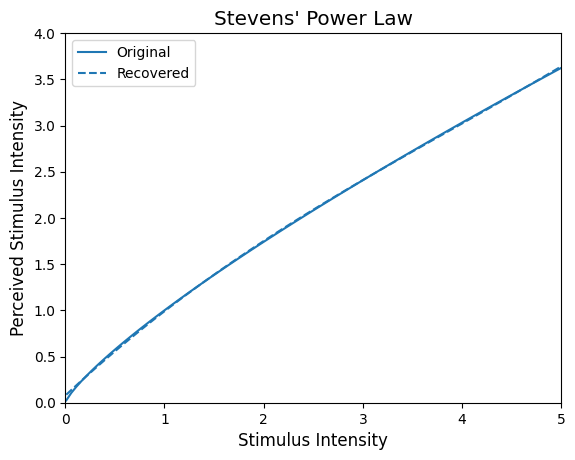

In [19]:
# run benchmark
benchmark(experiment_runner = stevens_power_law(), theorist = dummy_theorist)

#### EXPERIMENT CONDITIONS (X):
            S1        S2
0     0.010000  0.010000
1     0.010000  0.060404
2     0.010000  0.110808
3     0.010000  0.161212
4     0.010000  0.211616
...        ...       ...
5045  4.899192  4.949596
5046  4.899192  5.000000
5047  4.949596  4.949596
5048  4.949596  5.000000
5049  5.000000  5.000000

[5050 rows x 2 columns]
#### EXPERIMENT OBSERVATIONS (Y):
      difference_detected
0                0.003069
1                1.784709
2                2.404605
3                2.786509
4                3.065838
...                   ...
5045             0.023570
5046             0.013693
5047             0.002519
5048             0.023193
5049            -0.005341

[5050 rows x 1 columns]
#### IDENTIFIED EQUATION:
y1 = 0.957 + (-3.736) * S1 + (1.954) * S2 + (1.310) * S1^2 + (0.003) * S1 S2 + (-0.474) * S2^2 + (-0.160) * S1^3 + (0.009) * S1^2 S2 + (-0.005) * S1 S2^2 + (0.044) * S2^3
None
#### VALIDATION SET MSE:
difference_detected    0.140943
dtype: float6

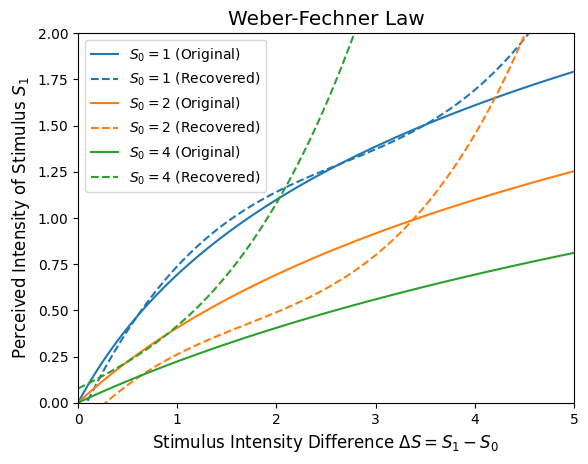

In [31]:
# run benchmark
benchmark(experiment_runner = weber_fechner_law(), theorist = dummy_theorist)

In [32]:
import numpy as np

# Define inputs (2 features)
x = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [2, 2],
    [3, 1],
    [3, 3],
])

# Define outputs using interaction formula
y = 1 + 2 * x[:, 0] + 3 * x[:, 1] + 4 * x[:, 0] * x[:, 1]
y = y.reshape(-1, 1)

# Fit with degree=1 (hybrid logic should add x0*x1 automatically)
model = PolynomialRegressor(degree=1)
model.fit(x, y)

# Print resulting equation
model.print_eqn()

y1 = -14.730 + (8.486) * x0 + (13.054) * x1
